In [1]:
from pathlib import Path

DATA_DIR = Path("output")

OUTPUT_DIR = Path("model_outputs")

RANDOM_STATE = 42

In [2]:
dataset_path = Path("output/dataset_winsize5h_where.csv")

In [3]:
import json

import pandas as pd

where_df = pd.read_csv(
    dataset_path,
    dtype={"fold_id": "int64"},
    converters={
        "window": json.loads,
        "label": json.loads,
    },
)

where_df.head()

,fold_id,window,label
0,0,"[{'from_zone_index': 16, 'to_zone_index': 16, ...","{'from_zone_index': 12, 'to_zone_index': 12}"
1,3,"[{'from_zone_index': 9, 'to_zone_index': 9, 'o...","{'from_zone_index': 17, 'to_zone_index': 17}"
2,2,"[{'from_zone_index': 20, 'to_zone_index': 20, ...","{'from_zone_index': 2, 'to_zone_index': 2}"
3,2,"[{'from_zone_index': 9, 'to_zone_index': 20, '...","{'from_zone_index': 22, 'to_zone_index': 22}"
4,1,"[{'from_zone_index': 2, 'to_zone_index': 2, 'o...","{'from_zone_index': 9, 'to_zone_index': 9}"


In [4]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

OUTAGE_TYPE_TO_ID = {
    "Planned": 0,
    "Auto": 1,
}


class WhereOutageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        window = row["window"]
        label = row["label"]

        outage_type = torch.tensor(
            [OUTAGE_TYPE_TO_ID[event["outage_type"]] for event in window],
            dtype=torch.long,
        )
        from_zone_indices = torch.tensor(
            [event["from_zone_index"] for event in window],
            dtype=torch.long,
        )
        to_zone_indices = torch.tensor(
            [event["to_zone_index"] for event in window],
            dtype=torch.long,
        )
        target = torch.tensor(
            [label["from_zone_index"], label["to_zone_index"]],
            dtype=torch.long,
        )

        return {
            "outage_type": outage_type,
            "from_zone_indices": from_zone_indices,
            "to_zone_indices": to_zone_indices,
            "target": target,
        }


TRAIN_FOLDS = [0, 1, 2, 3, 4]
TEST_FOLDS = [-1]

train_where_dataset = WhereOutageDataset(
    where_df[where_df["fold_id"].isin(TRAIN_FOLDS)]
)
test_where_dataset = WhereOutageDataset(where_df[where_df["fold_id"].isin(TEST_FOLDS)])

In [5]:
for i, sample_dict in enumerate(train_where_dataset):
    print(sample_dict)
    if i == 10:
        break

{'outage_type': tensor([0]), 'from_zone_indices': tensor([16]), 'to_zone_indices': tensor([16]), 'target': tensor([12, 12])}
{'outage_type': tensor([0]), 'from_zone_indices': tensor([9]), 'to_zone_indices': tensor([9]), 'target': tensor([17, 17])}
{'outage_type': tensor([0, 0]), 'from_zone_indices': tensor([20, 16]), 'to_zone_indices': tensor([20, 16]), 'target': tensor([2, 2])}
{'outage_type': tensor([0, 0, 0, 0, 0, 0, 0]), 'from_zone_indices': tensor([ 9,  2,  2, 11,  2,  2, 20]), 'to_zone_indices': tensor([20,  2,  2, 11,  2,  2, 20]), 'target': tensor([22, 22])}
{'outage_type': tensor([0, 0]), 'from_zone_indices': tensor([ 2, 20]), 'to_zone_indices': tensor([ 2, 20]), 'target': tensor([9, 9])}
{'outage_type': tensor([1, 0, 0]), 'from_zone_indices': tensor([9, 3, 0]), 'to_zone_indices': tensor([9, 3, 0]), 'target': tensor([8, 8])}
{'outage_type': tensor([0, 0]), 'from_zone_indices': tensor([2, 2]), 'to_zone_indices': tensor([2, 2]), 'target': tensor([15, 15])}
{'outage_type': tensor

In [6]:
import torch.nn as nn

ZONE_EMBEDDING_DIM = 64
OUTAGE_TYPE_EMBEDDING_DIM = 16
TRANSFORMER_DIM = 128
DROPOUT = 0.1

num_zones = int(
    max(
        where_df["label"]
        .map(lambda x: max(x["from_zone_index"], x["to_zone_index"]))
        .max(),
        max(
            max(event["from_zone_index"], event["to_zone_index"])
            for window in where_df["window"]
            for event in window
        ),
    )
    + 1
)
num_outage_types = len(OUTAGE_TYPE_TO_ID)


class WhereTransformer(nn.Module):
    def __init__(
        self,
        num_zones,
        num_outage_types,
        zone_embedding_dim=ZONE_EMBEDDING_DIM,
        outage_type_embedding_dim=OUTAGE_TYPE_EMBEDDING_DIM,
        transformer_dim=TRANSFORMER_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.num_zones = num_zones
        self.zone_embedding = nn.Embedding(num_zones, zone_embedding_dim)
        self.outage_type_embedding = nn.Embedding(
            num_outage_types,
            outage_type_embedding_dim,
        )
        self.input_fc = nn.Linear(
            2 * zone_embedding_dim + outage_type_embedding_dim,
            transformer_dim,
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=transformer_dim // 64,
            dim_feedforward=transformer_dim * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1,
        )
        self.projection = nn.Linear(transformer_dim, 2 * num_zones)

    def forward(self, from_zone_indices, to_zone_indices, outage_type, mask=None):
        from_zone_emb = self.zone_embedding(from_zone_indices)
        to_zone_emb = self.zone_embedding(to_zone_indices)
        outage_type_emb = self.outage_type_embedding(outage_type)

        x = torch.cat([from_zone_emb, to_zone_emb, outage_type_emb], dim=-1)
        x = self.input_fc(x)

        src_key_padding_mask = None
        if mask is not None:
            src_key_padding_mask = ~mask

        x = self.transformer_encoder(x, src_key_padding_mask=src_key_padding_mask)

        if mask is None:
            pooled = x.mean(dim=1)
        else:
            mask_float = mask.unsqueeze(-1).to(dtype=x.dtype)
            pooled = (x * mask_float).sum(dim=1) / mask_float.sum(dim=1).clamp_min(1.0)

        logits = self.projection(pooled)
        return logits.view(-1, 2, self.num_zones)


where_transformer = WhereTransformer(
    num_zones=num_zones,
    num_outage_types=num_outage_types,
)
where_transformer

WhereTransformer(
  (zone_embedding): Embedding(24, 64)
  (outage_type_embedding): Embedding(2, 16)
  (input_fc): Linear(in_features=144, out_features=128, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (projection): Linear(in_features=128, out_features=48, bias=True)
)

In [ ]:
LEARNING_RATE = 3e-6
NUM_EPOCHS = 30
VIRTUAL_BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def sample_to_device(sample, device):
    return {
        "from_zone_indices": sample["from_zone_indices"].unsqueeze(0).to(device),
        "to_zone_indices": sample["to_zone_indices"].unsqueeze(0).to(device),
        "outage_type": sample["outage_type"].unsqueeze(0).to(device),
        "target": sample["target"].unsqueeze(0).to(device),
        "mask": torch.ones(
            1,
            sample["outage_type"].numel(),
            dtype=torch.bool,
            device=device,
        ),
    }


def unordered_zone_loss(logits, target):
    from_logits = logits[:, 0, :]
    to_logits = logits[:, 1, :]
    target_from = target[:, 0]
    target_to = target[:, 1]

    forward_loss = nn.functional.cross_entropy(
        from_logits, target_from, reduction="none"
    ) + nn.functional.cross_entropy(to_logits, target_to, reduction="none")
    swapped_loss = nn.functional.cross_entropy(
        from_logits, target_to, reduction="none"
    ) + nn.functional.cross_entropy(to_logits, target_from, reduction="none")
    return torch.minimum(forward_loss, swapped_loss).mean()


def unordered_zone_correct_count(logits, target):
    pred = logits.argmax(dim=-1)
    pred_sorted = torch.sort(pred, dim=1).values
    target_sorted = torch.sort(target, dim=1).values
    return (pred_sorted == target_sorted).all(dim=1).sum().item()


where_transformer.to(DEVICE)
optimizer = torch.optim.Adam(where_transformer.parameters(), lr=LEARNING_RATE)

training_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    where_transformer.train()
    optimizer.zero_grad(set_to_none=True)

    train_loss_sum = 0.0
    train_correct = 0
    train_count = 0
    accumulated_samples = 0
    train_order = torch.randperm(len(train_where_dataset)).tolist()

    for sample_idx in train_order:
        batch = sample_to_device(train_where_dataset[sample_idx], DEVICE)
        logits = where_transformer(
            batch["from_zone_indices"],
            batch["to_zone_indices"],
            batch["outage_type"],
            batch["mask"],
        )
        loss = unordered_zone_loss(logits, batch["target"])
        (loss / VIRTUAL_BATCH_SIZE).backward()

        train_loss_sum += loss.item()
        train_correct += unordered_zone_correct_count(logits, batch["target"])
        train_count += 1
        accumulated_samples += 1

        if accumulated_samples == VIRTUAL_BATCH_SIZE:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            accumulated_samples = 0

    if accumulated_samples:
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    train_loss = train_loss_sum / train_count
    train_accuracy = train_correct / train_count

    where_transformer.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_count = 0

    with torch.no_grad():
        for sample_idx in range(len(test_where_dataset)):
            batch = sample_to_device(test_where_dataset[sample_idx], DEVICE)
            logits = where_transformer(
                batch["from_zone_indices"],
                batch["to_zone_indices"],
                batch["outage_type"],
                batch["mask"],
            )
            loss = unordered_zone_loss(logits, batch["target"])

            test_loss_sum += loss.item()
            test_correct += unordered_zone_correct_count(logits, batch["target"])
            test_count += 1

    test_loss = test_loss_sum / test_count
    test_accuracy = test_correct / test_count

    epoch_metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }
    training_history.append(epoch_metrics)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_loss:.6f}, train acc={train_accuracy:.4f} | "
        f"test loss={test_loss:.6f}, test acc={test_accuracy:.4f}"
    )

/home/aj/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 001 | train loss=6.494243, train acc=0.0017 | test loss=6.449917, test acc=0.0042
Epoch 002 | train loss=6.309561, train acc=0.0056 | test loss=6.278746, test acc=0.0067
Epoch 003 | train loss=6.142458, train acc=0.0132 | test loss=6.127035, test acc=0.0192
Epoch 004 | train loss=5.995088, train acc=0.0501 | test loss=5.995995, test acc=0.0718
Epoch 005 | train loss=5.871242, train acc=0.0890 | test loss=5.884148, test acc=0.0952
Epoch 006 | train loss=5.763684, train acc=0.1061 | test loss=5.790144, test acc=0.1019
Epoch 007 | train loss=5.676076, train acc=0.1153 | test loss=5.712080, test acc=0.1145
Epoch 008 | train loss=5.600100, train acc=0.1279 | test loss=5.646277, test acc=0.1211
Epoch 009 | train loss=5.539216, train acc=0.1285 | test loss=5.591112, test acc=0.1220
Epoch 010 | train loss=5.488744, train acc=0.1323 | test loss=5.544133, test acc=0.1287
Epoch 011 | train loss=5.440616, train acc=0.1392 | test loss=5.504660, test acc=0.1278
Epoch 012 | train loss=5.400308,

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,6.494243,0.001672,6.449917,0.004177
1,2,6.309561,0.005641,6.278746,0.006683
2,3,6.142458,0.013163,6.127035,0.019215
3,4,5.995088,0.050146,5.995995,0.071846
4,5,5.871242,0.089010,5.884148,0.095238
5,6,5.763684,0.106143,5.790144,0.101921
6,7,5.676076,0.115336,5.712080,0.114453
7,8,5.600100,0.127873,5.646277,0.121136
8,9,5.539216,0.128500,5.591112,0.121972
9,10,5.488744,0.132261,5.544133,0.128655


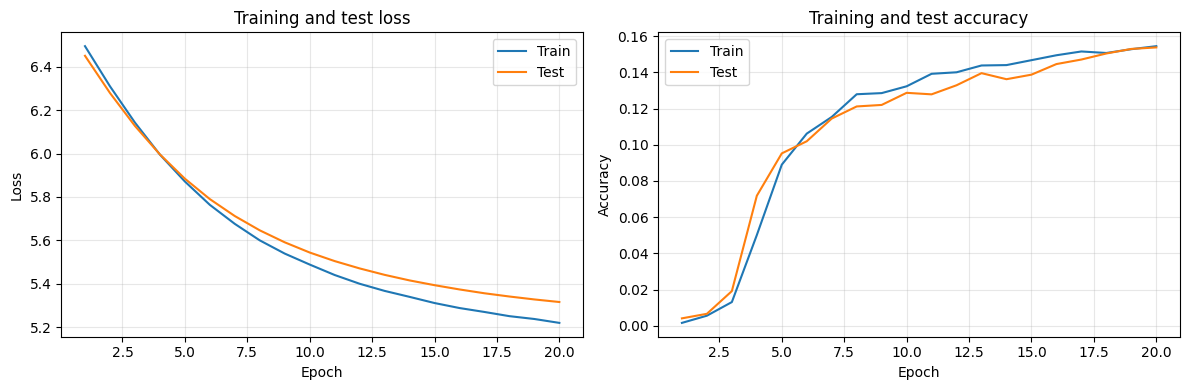

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    training_history_df["epoch"], training_history_df["train_loss"], label="Train"
)
axes[0].plot(
    training_history_df["epoch"], training_history_df["test_loss"], label="Test"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and test loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    training_history_df["epoch"],
    training_history_df["train_accuracy"],
    label="Train",
)
axes[1].plot(
    training_history_df["epoch"],
    training_history_df["test_accuracy"],
    label="Test",
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and test accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()